In [1]:
%%capture
!unset LD_PRELOAD
import os
os.environ.pop('LD_PRELOAD', None)

In [ ]:
%%bash 
pip install uv
uv pip install jupyter matplotlib numpy pandas torch==2.5.0 torchviz gymnasium engression stable-baselines3

# setup osmesa cpu backend for mujoco
conda install -c conda-forge mesalib
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa

uv pip install mujoco

Using Python 3.11.10 environment at: /opt/conda
Resolved 133 packages in 463ms
Uninstalled 14 packages in 853ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 18 packages in 25.59s
 + engression==0.1.12
 - nvidia-cublas-cu12==12.3.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.3.101
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.3.107
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.3.101
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==8.9.7.29
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.0.12.1
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.4.107
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-cu12==11.5.4.101
 + nvidia-cusolver-cu12==11.6.1.9
 - nvidia-cusparse-cu12==12.2.0.103
 + nvidia-cusparse-cu12==1

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done




==> WARNING: A newer version of conda exists. <==
    current version: 24.9.1
    latest version: 25.9.0

Please update conda by running

    $ conda update -n base -c conda-forge conda





## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - mesalib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blas-2.136                 |         openblas          17 KB  conda-forge
    blas-devel-3.9.0           |36_h1ea3ea9_openblas          17 KB  conda-forge
    ca-certificates-2025.8.3   |       hbd8a1cb_0         151 KB  conda-forge
    certifi-2025.8.3           |     pyhd8ed1ab_0         155 KB  conda-forge
    expat-2.7.1                |       hecca717_0         138 KB  conda-forge
    libblas-3.9.0              |36_h4a7cf45_openblas          17 KB  conda-forge
    libcblas-3.9.0             |36_h0358290_openblas          17 KB  conda-forge
    libdrm-2.4.125             |       hb03c661_1         304 KB  conda-forge
    libexpat-2.7.1             |       hecca717_0          73 KB  conda-forge
    libgcc-15.1.0              |       h767d61c

In [4]:
# vectorized environments (parallel training on multiple envs) --> https://gymnasium.farama.org/tutorials/training_agents/vector_a2c/

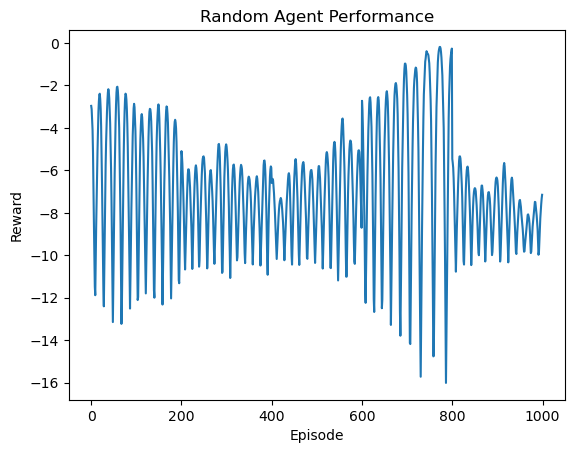

In [5]:

import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array", g=10.0)
observation, info = env.reset(seed=42)

rewards = []
trajectories = []
for _ in range(1000):
    current_state = observation
    action = env.action_space.sample()  
    # current_action = action
    observation, reward, terminated, truncated, info = env.step(action)
    next_state = observation

    rewards.append(reward)
    trajectories.append((current_state, action, reward, next_state))



    if terminated or truncated:
        observation, info = env.reset()

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

# Benchmark Generalization between MLPs and Engression Networks on Control Tasks
- implement CNN-VAE encoder to learn latents, learn encoder and dynamics model jointly 
- use a CEM or MPC planner with a learned dynamics model to simulate trajectories and select the next best action (instead of training a policy)
    - rationale: planning is heavily reliant on the accuracy of the learned dynamics model, so if the dynamics model is not accurate, planning will fail

## Benchmark accross several environments
- Pendulum-v1
    - modify the gravity of the Pendulum-v1 environment to see if the model can adapt
    - bias the torque / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different gravity settings (6.0, 8.0, 12.0, 14.0) and different torque bias settings (0.0, 0.5, 1.0)

- CartPole-v1
    - modify the length of the pole to see if the model can adapt
    - bias the force / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different pole length settings (0.5, 0.7, 1.3, 1.5) and different force bias settings (0.0, 0.5, 1.0)
    
- Acrobot-v1
    - modify the length of the links to see if the model can adapt
    - bias the torque / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different link length settings (0.5, 0.7, 1.3, 1.5) and different torque bias settings (0.0, 0.5, 1.0)

```
# factorized representation learning for control
enc(o) -> s_latent, noise_latent

dec(s_latent, noise_latent) -> o_recon

pi(a | s_latent) -> a

k(a) -> a_latent

f(s_latent, a_latent) -> s'_latent

r(s_latent, a_latent, s'_latent) -> r

---
# encode
s, a_lat, z_noise = encoder(o)

# dynamics loss
s_pred = transition(s, action)
s_next, _, _ = encoder(o_next)
loss_dyn = mse_loss(s_pred, s_next)

# policy loss (e.g. imitation)
action_pred = policy(a_lat)
loss_pi = cross_entropy(action_pred, action)

# reconstruction loss
o_hat = decoder(s, a_lat, z_noise)
loss_recon = mse_loss(o_hat, o)

# disentanglement regularization
loss_reg = orthogonality_penalty([s, a_lat, z_noise])

# total
loss = loss_dyn + λ1*loss_pi + λ2*loss_recon + λ3*loss_reg

```

In [8]:
from __future__ import annotations
from typing import Tuple, List, Union, Optional, Dict, Any, Callable
import torch
import numpy as np  
import matplotlib.pyplot as plt
from torch import nn, optim
import matplotlib.pyplot as plt
from engression.loss_func import energy_loss, energy_loss_two_sample
from engression.utils import vectorize, cor, check_for_gpu, make_folder
from engression.models import StoNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


class Env(object):
    ''' 
    Wrapper for Gym environments to handle both feature and image-based states.
    When use_images is True, states are images of shape frame_shape (C, H, W).
    '''
    def __init__(self, env_name='Pendulum-v1', use_images=False, frame_shape=(3, 64, 64), gravity=10.0, seed=42):
        self.env = gym.make(env_name, render_mode="rgb_array", g=gravity, max_episode_steps=200)
        self.use_images = use_images
        self.frame_shape = frame_shape
        self.gravity = gravity
        self.seed = seed

        self.state, self.info = self.env.reset(seed=seed)
        if use_images:
            self.state = self.render() # (H, W, C)
        self.state_dim = self.state.shape[0] if not use_images else self.state.shape
        self.action_dim = self.env.action_space.shape[0]
        self.action_low = self.env.action_space.low
        self.action_high = self.env.action_space.high

        # ensure consistency
        self.action_space = self.env.action_space
        # self.observation_space = self.env.observation_space

    def step(self, action):
        if self.use_images:
            return self.step_img(action)
        else:
            return self.step_feats(action)

    def step_feats(self, action):
        action = np.clip(action, self.action_low, self.action_high)
        next_state, reward, terminated, truncated, info = self.env.step(action)
        # done = terminated or truncated
        return next_state, reward, terminated, truncated, info

    def step_img(self, action):
        action = np.clip(action, self.action_low, self.action_high)
        _, reward, terminated, truncated, info = self.env.step(action)
        img_next_state = self.render()
        # done = terminated or truncated
        return img_next_state, reward, terminated, truncated, info
    
    def _resize_frame(self, frame):
        from PIL import Image
        if self.frame_shape is None:
            return frame
        return np.asarray(
            Image.fromarray(frame).resize((self.frame_shape[2], self.frame_shape[1]))
            ).transpose(2, 0, 1) # to convert (H, W, C) to (C, H, W) for downstream CNNs

    def reset(self):
        self.state, self.info = self.env.reset()
        if self.use_images:
            self.state = self.render()
        return self.state, self.info

    def render(self):
        return self._resize_frame(self.env.render())

    def close(self):
        self.env.close()


# class ReplayBuffer:
#     def __init__(self, capacity=10000):
#         self.capacity = capacity
#         self.buffer = []
#         self.position = 0

#     def push(self, state, action, reward, next_state):
#         if len(self.buffer) < self.capacity:
#             self.buffer.append(None)
#         self.buffer[self.position] = (state, action, reward, next_state)
#         self.position = (self.position + 1) % self.capacity

#     def sample(self, batch_size):
#         indices = np.random.choice(len(self.buffer), batch_size, replace=False)
#         batch = [self.buffer[idx] for idx in indices]
#         state, action, reward, next_state = map(torch.stack, zip(*batch))
#         return state, action, reward, next_state

#     def batch_sample(self, batch_size):
#         if len(self.buffer) < batch_size:
#             return None
#         return self.sample(batch_size)

# replay_buffer = ReplayBuffer(capacity=10000)

# def sample_from_replay_buffer(batch_size=64):
#     return replay_buffer.batch_sample(batch_size)


# class ReplayBuffer:
#     def __init__(self, capacity=10000):
#         self.capacity = capacity
#         self.buffer = []
#         self.position = 0
    
#     def push(self, state, action, reward, next_state):
#         if len(self.buffer) < self.capacity:
#             self.buffer.append(None)
#         self.buffer[self.position] = (state, action, reward, next_state)
#         self.position = (self.position + 1) % self.capacity
    
#     def sample(self, batch_size=64):
#         batch = torch.randperm(len(self.buffer))[:batch_size]
#         state, action, reward, next_state = map(torch.stack, zip(*[self.buffer[i] for i in batch]))
#         return state, action, reward, next_state
    
#     def batch_sample(self, batch_size=64):
#         # ensure we use Python ints for indexing and handle stored tensor elements correctly
#         indices = torch.randperm(len(self.buffer))[:batch_size].tolist()
#         states, actions, rewards, next_states = zip(*[self.buffer[idx] for idx in indices])
#         # If the stored elements are already torch.Tensors, stack them directly.
#         if isinstance(states[0], torch.Tensor):
#             states = torch.stack(states).to(DEVICE)
#             actions = torch.stack(actions).to(DEVICE)
#             rewards = torch.stack(rewards).to(DEVICE)
#             next_states = torch.stack(next_states).to(DEVICE)
#         else:
#             # fallback if numpy arrays were stored
#             states = torch.tensor(states, dtype=torch.float32).to(DEVICE)
#             actions = torch.tensor(actions, dtype=torch.float32).to(DEVICE)
#             rewards = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
#             next_states = torch.tensor(next_states, dtype=torch.float32).to(DEVICE)
#         return states, actions, rewards, next_states
    
#     def __len__(self):
#         return len(self.buffer)


class ReplayBuffer:
    def __init__(self, capacity=10000, device=DEVICE, dtype=torch.float32):
        self.capacity = capacity
        self.device = device
        self.dtype = dtype
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (
            self._prepare(state),
            self._prepare(action),
            self._prepare_reward(reward),
            self._prepare(next_state),
        )
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size, replace=False):
        if len(self.buffer) < batch_size and not replace:
            raise ValueError("Not enough samples in buffer.")
        indices = np.random.choice(len(self.buffer), batch_size, replace=replace)
        batch = [self.buffer[idx] for idx in indices]
        states, actions, rewards, next_states = zip(*batch)
        return (
            torch.stack(states).to(self.device),
            torch.stack(actions).to(self.device),
            torch.stack(rewards).to(self.device),
            torch.stack(next_states).to(self.device),
        )

    def batch_sample(self, batch_size, replace=False):
        if len(self.buffer) < batch_size and not replace:
            return None
        return self.sample(batch_size, replace=replace)

    def __len__(self):
        return len(self.buffer)

    def _prepare(self, value):
        if isinstance(value, torch.Tensor):
            return value.detach().to(self.device)
        return torch.as_tensor(value, dtype=self.dtype, device=self.device)

    def _prepare_reward(self, reward):
        reward_tensor = self._prepare(reward)
        if reward_tensor.dim() == 0:
            reward_tensor = reward_tensor.unsqueeze(0)
        return reward_tensor
    

def sample_from_replay_buffer(replay_buffer, batch_size=64):
    return replay_buffer.batch_sample(batch_size)

# simple CNN Encoder
class Enc(nn.Module):
    def __init__(self, in_dim=(3, 64, 64), latent_dim=64):
        super(Enc, self).__init__()
        self.latent_dim = latent_dim
        self.enc = nn.Sequential(
            nn.Conv2d(in_dim[0], 32, kernel_size=4, stride=2, padding=1),  # out: (32, 32, 32)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),        # out: (64, 16, 16)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),        # out: (64, 8, 8)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),        # out: (64, 4, 4)
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, latent_dim), # Input size is 1024
            nn.ReLU(), # only positive pixel values
        )

    def forward(self, x):
        return self.enc(x)
    

class Dec(nn.Module):
    def __init__(self, latent_dim=64, out_dim=(3, 64, 64)):
        super(Dec, self).__init__()
        self.latent_dim = latent_dim
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1), # out: (64, 8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # out: (32, 16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1), # out: (32, 32, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(32, out_dim[0], kernel_size=4, stride=2, padding=1), # out: (3, 64, 64)
            nn.Sigmoid(), # ensure pixel values are between 0 and 1
        )

    def forward(self, x):
        return self.dec(x)
        


class WorldModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(WorldModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)  # Predict next state only
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)



class RewardModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=16):
        super(RewardModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim + state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # Predict reward
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x)
    


class EngressionWorldModel(nn.Module):
    def __init__(
            self, 
            state_dim, 
            action_dim,
            num_layer,
            hidden_dim,
            noise_dim,
            add_bn=True,
            out_act=False, 
            resblock=False,
    ):
        super(EngressionWorldModel, self).__init__()
        self.model = StoNet(
            in_dim=state_dim + action_dim,
            out_dim=state_dim,
            num_layer=num_layer,
            hidden_dim=hidden_dim,
            noise_dim=noise_dim,
            add_bn=add_bn,
            out_act=out_act,
            resblock=resblock,
        ).to(DEVICE)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)
    

class EngressionRewardModel(nn.Module):
    def __init__(
            self, 
            state_dim, 
            action_dim,
            num_layer,
            hidden_dim,
            noise_dim,
            add_bn=True,
            out_act=False, 
            resblock=False,
    ):
        super(EngressionRewardModel, self).__init__()
        self.model = StoNet(
            in_dim=state_dim + action_dim + state_dim,
            out_dim=1,
            num_layer=num_layer,
            hidden_dim=hidden_dim,
            noise_dim=noise_dim,
            add_bn=add_bn,
            out_act=out_act,
            resblock=resblock,
        ).to(DEVICE)

    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x)

Using device: cuda


```python
EngressionWorldModel(
  (model): StoNet(
    (input_layer): StoLayer(
      (layer): Sequential(
        (0): Linear(in_features=12, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (out_act): ReLU(inplace=True)
    )
    (inter_layer): Sequential(
      (0): StoLayer(
        (layer): Sequential(
          (0): Linear(in_features=72, out_features=64, bias=True)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (out_act): ReLU(inplace=True)
      )
      (1): StoLayer(
        (layer): Sequential(
          (0): Linear(in_features=72, out_features=64, bias=True)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (out_act): ReLU(inplace=True)
      )
    )
    (out_layer): Linear(in_features=64, out_features=3, bias=True)
  )
)
```

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


(3, 64, 64)
(3, 64, 64)


torch.Size([1, 3, 64, 64])

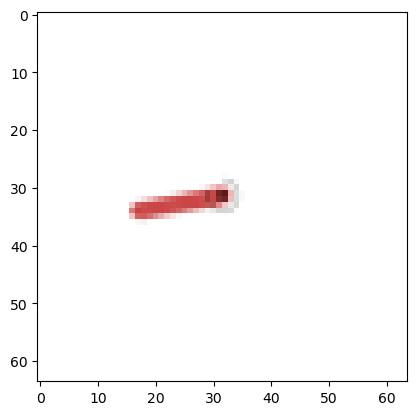

In [7]:

env = Env("Pendulum-v1", use_images=True, seed=42)
print(env.state.shape)
enc = Enc(in_dim=env.state_dim, latent_dim=64).to(DEVICE)
dec = Dec(latent_dim=64, out_dim=env.state_dim).to(DEVICE)
frame = env.state
action = env.action_space.sample()
next_frame, reward, terminated, truncated, info = env.step(action)
plt.imshow(next_frame.transpose(1, 2, 0))
print(next_frame.shape)
enc(torch.tensor(next_frame).unsqueeze(0).to(DEVICE)/255.0)
dec(enc(torch.tensor(next_frame).unsqueeze(0).to(DEVICE)/255.0)).shape

In [19]:
env = Env("Pendulum-v1", use_images=True, seed=42)
print(f"State dim: {env.state_dim}, Action dim: {env.action_dim}")


State dim: (3, 64, 64), Action dim: 1


Total number of parameters: 241760
Sampled states shape: torch.Size([64, 3, 64, 64]), actions shape: torch.Size([64, 1]), next_states shape: torch.Size([64, 3, 64, 64])
Epoch 0, Loss: 1.3686, Recon Loss: 127898.3516


/tmp/ipykernel_387/1510767141.py:99: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  reward_loss = nn.functional.mse_loss(reward_preds.squeeze(), rewards)


Sampled states shape: torch.Size([64, 3, 64, 64]), actions shape: torch.Size([64, 1]), next_states shape: torch.Size([64, 3, 64, 64])
Epoch 10, Loss: 0.8200, Recon Loss: 127884.1094
Epoch 20, Loss: 0.7300, Recon Loss: 127736.0234
Epoch 30, Loss: 0.5627, Recon Loss: 127503.0703
Epoch 40, Loss: 0.5504, Recon Loss: 127487.9062
Epoch 50, Loss: 0.4943, Recon Loss: 127448.8828
Epoch 60, Loss: 0.4139, Recon Loss: 127451.7344
Epoch 70, Loss: 0.3953, Recon Loss: 127486.8359
Epoch 80, Loss: 0.3391, Recon Loss: 127458.7109
Epoch 90, Loss: 0.3299, Recon Loss: 127510.5156
Epoch 100, Loss: 0.2863, Recon Loss: 127499.8359
Epoch 110, Loss: 0.2687, Recon Loss: 127459.9141
Epoch 120, Loss: 0.2456, Recon Loss: 127484.7422
Epoch 130, Loss: 0.2196, Recon Loss: 127448.2031
Epoch 140, Loss: 0.2120, Recon Loss: 127489.2188
Epoch 150, Loss: 0.1925, Recon Loss: 127458.1250
Epoch 160, Loss: 0.1826, Recon Loss: 127491.8672
Epoch 170, Loss: 0.1832, Recon Loss: 127504.0703
Epoch 180, Loss: 0.1666, Recon Loss: 12744

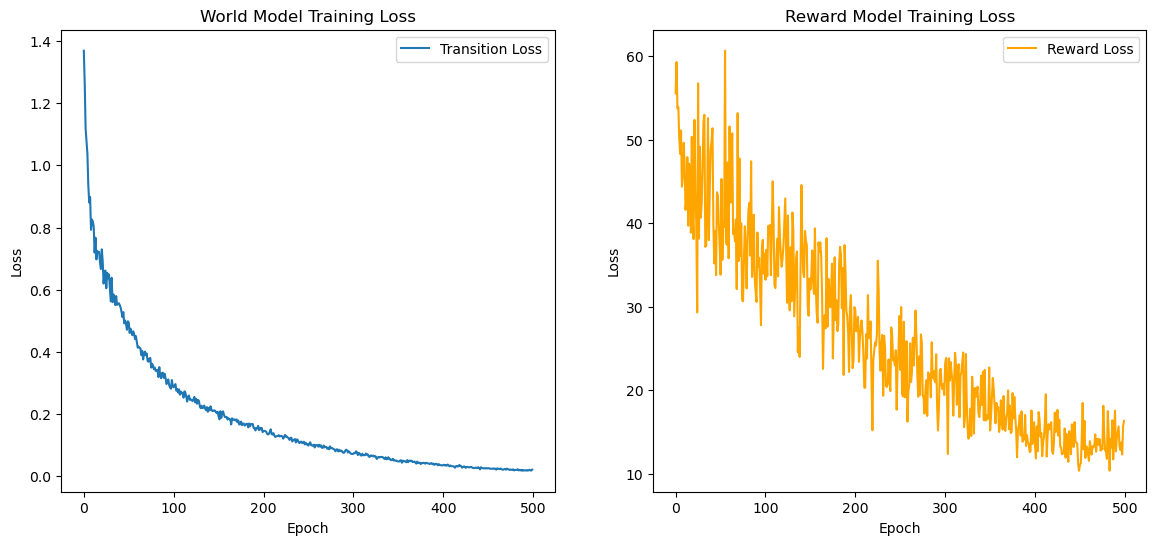

In [ ]:
env = Env("Pendulum-v1", use_images=True, seed=42)
enc = Enc(in_dim=env.state_dim, latent_dim=64).to(DEVICE) if env.use_images else None
dec = Dec(latent_dim=64, out_dim=env.state_dim).to(DEVICE) if env.use_images else None

world_model = EngressionWorldModel(
    state_dim=env.state_dim if not env.use_images else enc.latent_dim, 
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=64,
    noise_dim=32,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

reward_model = EngressionRewardModel(
    state_dim=env.state_dim if not env.use_images else enc.latent_dim, 
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=16,
    noise_dim=16,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

replay_buffer = ReplayBuffer(capacity=10000, device=DEVICE)

params_to_optimize = list(world_model.parameters())
if enc is not None:
    # optimize transition model & encoder jointly
    params_to_optimize.extend(list(enc.parameters()))

world_model_optimizer = optim.Adam(params_to_optimize, lr=1e-3)
reward_optimizer = optim.Adam(reward_model.parameters(), lr=1e-3) if reward_model is not None else None
# reward_optimizer = optim.Adam(reward_model.parameters(), lr=1e-3) if reward_model is not None else None
reconstruction_optimizer = optim.Adam(dec.parameters(), lr=1e-3) if dec is not None else None


total_params = sum(p.numel() for p in params_to_optimize if p.requires_grad)
print(f'Total number of parameters: {total_params}')



num_epochs = 500
batch_size = 64
losses = []
reward_losses = []
recon_losses = []
for epoch in range(num_epochs):
    o = env.reset()[0]
    for _ in range(64):  # Collect some data
        action = env.action_space.sample()
        noisy_action = action 
        # noisy_action = action + np.random.normal(0, 2) + 1.1  # bias the torque to the right
        next_o, reward, done, truncated, info = env.step(noisy_action)
        # Store transition (o, action, reward, next_o)
        replay_buffer.push(torch.tensor(o, dtype=torch.float32).to(DEVICE),
                           torch.tensor(action, dtype=torch.float32).to(DEVICE),
                           torch.tensor(reward, dtype=torch.float32).to(DEVICE),
                           torch.tensor(next_o, dtype=torch.float32).to(DEVICE))
        o = next_o 
        if done or truncated:
            o, info = env.reset()

    world_model.zero_grad() # reset gradients
    world_model_optimizer.zero_grad()
    # reward_optimizer.zero_grad() if reward_optimizer is not None else None
    reconstruction_optimizer.zero_grad()
    
    states, actions, rewards, next_states = sample_from_replay_buffer(replay_buffer, batch_size)

    if epoch <= 1:
        print(f"Sampled states shape: {states.shape}, actions shape: {actions.shape}, next_states shape: {next_states.shape}")

    if enc is not None:
        enc.zero_grad()
        # get latent representations of images
        # enc is defined if env.use_images is True
        _states_images = states
        _next_states_images = next_states
        states = enc(states/255.0)
        next_states = enc(next_states/255.0)

        # reconstruction loss of the decoder (only optimize decoder here)
        if dec is not None:
            dec.zero_grad()
            recon_states = dec(states.detach()) # prevent backprop into encoder
            recon_next_states = dec(next_states.detach()) # prevent backprop into encoder
            recon_loss = nn.functional.mse_loss(recon_states, _states_images) + nn.functional.mse_loss(recon_next_states, _next_states_images)
            recon_loss.backward()
            reconstruction_optimizer.step()
            recon_losses.append(recon_loss.item())
    # optimize reward model
    if reward_model is not None and reward_optimizer is not None:
        reward_model.zero_grad()
        reward_optimizer.zero_grad()
        reward_preds = reward_model(states.detach(), actions.detach(), next_states.detach()) # prevent backprop into encoder & world model
        reward_loss = nn.functional.mse_loss(reward_preds.squeeze(), rewards)
        reward_loss.backward()
        reward_optimizer.step()
        reward_losses.append(reward_loss.item())

    # world model uses latents as input
    y_sample1 = world_model(states, actions)
    y_sample2 = world_model(states, actions)
    loss, loss1, loss2 = energy_loss_two_sample(next_states, y_sample1, y_sample2, beta=1.0, verbose=True) # verbose to return all 3 losses

    loss.backward()
    world_model_optimizer.step()
    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Recon Loss: {recon_loss.item():.4f}" if dec is not None else f"Epoch {epoch}, Loss: {loss.item():.4f}")
        # print(f"Epoch {epoch}, Loss: {loss.item():.4f}, E(|Y-Yhat|): {loss1.item():.4f}, E(|Yhat-Yhat'|): {loss2.item():.4f}")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(losses, label='Transition Loss')
ax[1].plot(reward_losses, label='Reward Loss', color='orange')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("World Model Training Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Reward Model Training Loss")
ax[0].legend()
ax[1].legend()
plt.show()

Epoch 0, JointLoss:2.9690, Dyn:1.4606, Recon:0.5084, VarPen:0.1000, CovPen:0.0000
Epoch 10, JointLoss:2.3047, Dyn:0.8346, Recon:0.4702, VarPen:0.1000, CovPen:0.0000
Epoch 20, JointLoss:1.8493, Dyn:0.6862, Recon:0.1631, VarPen:0.1000, CovPen:0.0000
Epoch 30, JointLoss:1.6352, Dyn:0.6135, Recon:0.0218, VarPen:0.1000, CovPen:0.0000
Epoch 40, JointLoss:1.5664, Dyn:0.5549, Recon:0.0115, VarPen:0.1000, CovPen:0.0000
Epoch 50, JointLoss:1.4797, Dyn:0.4697, Recon:0.0100, VarPen:0.1000, CovPen:0.0000
Epoch 60, JointLoss:1.4231, Dyn:0.4137, Recon:0.0094, VarPen:0.1000, CovPen:0.0000
Epoch 70, JointLoss:1.4074, Dyn:0.3981, Recon:0.0094, VarPen:0.1000, CovPen:0.0000
Epoch 80, JointLoss:1.3452, Dyn:0.3359, Recon:0.0093, VarPen:0.1000, CovPen:0.0000
Epoch 90, JointLoss:1.3164, Dyn:0.3071, Recon:0.0093, VarPen:0.1000, CovPen:0.0000
Epoch 100, JointLoss:1.2997, Dyn:0.2906, Recon:0.0091, VarPen:0.1000, CovPen:0.0000
Epoch 110, JointLoss:1.2772, Dyn:0.2680, Recon:0.0092, VarPen:0.1000, CovPen:0.0000
Epo

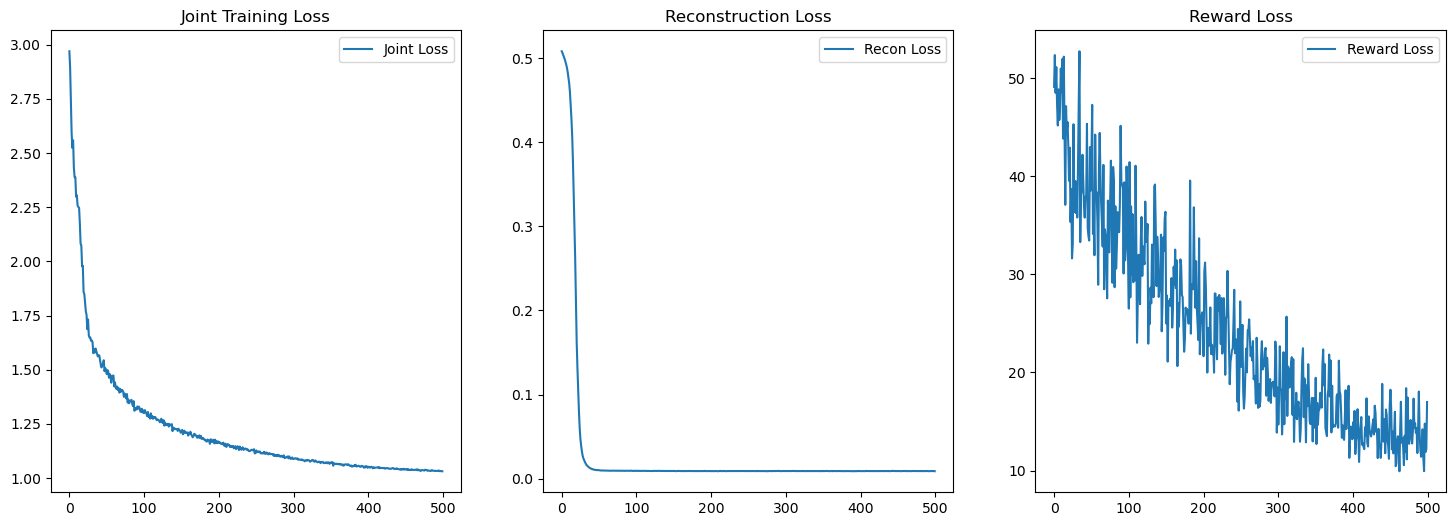

In [25]:
# -------------------- setup --------------------
env = Env("Pendulum-v1", use_images=True, seed=42)
enc = Enc(in_dim=env.state_dim, latent_dim=64).to(DEVICE) if env.use_images else None
dec = Dec(latent_dim=64, out_dim=env.state_dim).to(DEVICE) if env.use_images else None

world_model = EngressionWorldModel(
    state_dim=env.state_dim if not env.use_images else enc.latent_dim,
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=64,
    noise_dim=32,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

reward_model = EngressionRewardModel(
    state_dim=env.state_dim if not env.use_images else enc.latent_dim,
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=16,
    noise_dim=16,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

replay_buffer = ReplayBuffer(capacity=10000, device=DEVICE)

# Optimizers:
# world_optimizer updates world_model + encoder
params_world = list(world_model.parameters())
if enc is not None:
    params_world += list(enc.parameters())
world_optimizer = optim.Adam(params_world, lr=1e-3)

# reconstruction optimizer updates decoder only (encoder grads flow but are applied by world_optimizer)
recon_optimizer = optim.Adam(dec.parameters(), lr=1e-3) if dec is not None else None

reward_optimizer = optim.Adam(reward_model.parameters(), lr=1e-3) if reward_model is not None else None

# regularizers
def latent_variance_penalty(latents, margin=0.1):
    var = latents.var(dim=0, unbiased=False)
    return torch.relu(margin - var).mean()

def latent_covariance_penalty(latents):
    N, D = latents.shape
    if N <= 1:
        return torch.tensor(0., device=latents.device)
    lat = latents - latents.mean(dim=0, keepdim=True)
    cov = (lat.T @ lat) / (N - 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return (off_diag**2).sum() / (D * D)

L_VAR = 10.0
L_COV = 1.0
RECON_WEIGHT = 1.0
CLIP_NORM = 5.0

# -------------------- training --------------------
num_epochs = 500
batch_size = 64
losses = []
reward_losses = []
recon_losses = []

for epoch in range(num_epochs):
    # collect data
    o = env.reset()[0]
    for _ in range(64):
        action = env.action_space.sample()
        next_o, reward, done, truncated, info = env.step(action)
        replay_buffer.push(o, action, float(reward), next_o)
        o = next_o
        if done or truncated:
            o, info = env.reset()

    sample = sample_from_replay_buffer(replay_buffer, batch_size)
    if sample is None:
        continue
    states, actions, rewards, next_states = sample  # tensors on DEVICE

    # normalization for images
    if enc is not None:
        states_img = states / 255.0
        next_states_img = next_states / 255.0
        latents = enc(states_img)
        next_latents = enc(next_states_img)
    else:
        latents = states
        next_latents = next_states

    # compute reconstruction loss (but do NOT call backward here)
    if dec is not None:
        recon_states = dec(latents)
        recon_next_states = dec(next_latents)
        recon_loss = nn.functional.mse_loss(recon_states, states_img) + nn.functional.mse_loss(recon_next_states, next_states_img)
    else:
        recon_loss = torch.tensor(0., device=DEVICE)

    # dynamics loss (energy loss two-sample)
    y1 = world_model(latents, actions)
    y2 = world_model(latents, actions)
    dyn_loss, l1, l2 = energy_loss_two_sample(next_latents, y1, y2, beta=1.0, verbose=True)

    # regularizers
    var_pen = latent_variance_penalty(latents, margin=0.1)
    cov_pen = latent_covariance_penalty(latents)
    reg_loss = L_VAR * var_pen + L_COV * cov_pen

    # joint loss for encoder + world_model + decoder grads (decoder updated by recon_optimizer)
    total_joint_loss = dyn_loss + reg_loss + RECON_WEIGHT * recon_loss

    # zero grads
    world_optimizer.zero_grad()
    if recon_optimizer is not None:
        recon_optimizer.zero_grad()
    if reward_optimizer is not None:
        reward_optimizer.zero_grad()

    # backward once for joint graph (enc + world_model + decoder)
    total_joint_loss.backward()
    # clip grads for world + encoder
    torch.nn.utils.clip_grad_norm_(params_world, CLIP_NORM)
    world_optimizer.step()
    # decoder step (decoder grads were created in backward and are updated here)
    if recon_optimizer is not None:
        torch.nn.utils.clip_grad_norm_(dec.parameters(), CLIP_NORM)
        recon_optimizer.step()

    # reward model trained separately with detached latents
    if reward_model is not None and reward_optimizer is not None:
        reward_optimizer.zero_grad()
        reward_preds = reward_model(latents.detach(), actions.detach(), next_latents.detach())
        reward_targets = rewards.view(reward_preds.shape[0], -1).squeeze()
        reward_loss = nn.functional.mse_loss(reward_preds.squeeze(), reward_targets)
        reward_loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), CLIP_NORM)
        reward_optimizer.step()
        reward_losses.append(reward_loss.item())

    losses.append(total_joint_loss.item())
    if dec is not None:
        recon_losses.append(recon_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, JointLoss:{total_joint_loss.item():.4f}, Dyn:{dyn_loss.item():.4f}, Recon:{recon_loss.item():.4f}, VarPen:{var_pen.item():.4f}, CovPen:{cov_pen.item():.4f}")

# plotting
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].plot(losses, label='Joint Loss')
ax[0].set_title("Joint Training Loss")
ax[1].plot(recon_losses, label='Recon Loss')
ax[1].set_title("Reconstruction Loss")
ax[2].plot(reward_losses, label='Reward Loss')
ax[2].set_title("Reward Loss")
for a in ax:
    a.legend()
plt.show()

In [33]:
# Full corrected training script (replace your previous training section)
# Assumes classes and imports from your earlier code exist (Env, Enc, Dec, EngressionWorldModel, EngressionRewardModel, ReplayBuffer, energy_loss_two_sample, StoNet, DEVICE)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# -------------------- helper utilities --------------------
def make_center_weight(h, w, sigma_scale=0.5, device="cpu"):
    """Gaussian center-weight mask emphasizing the middle of the image."""
    ys = torch.linspace(-1.0, 1.0, steps=h, device=device)
    xs = torch.linspace(-1.0, 1.0, steps=w, device=device)
    Y, X = torch.meshgrid(ys, xs, indexing="ij")
    sigma = sigma_scale
    gauss = torch.exp(- (X**2 + Y**2) / (2 * sigma**2))
    # normalize to max 1
    gauss = gauss / gauss.max()
    return gauss  # (H, W)

def info_nce_loss(query, positive, temperature=0.07):
    """
    Simple InfoNCE: queries shape (B, D), positive shape (B, D).
    Negatives are other positives in the batch.
    """
    q = F.normalize(query, dim=-1)  # (B, D)
    k = F.normalize(positive, dim=-1)  # (B, D)
    logits = q @ k.t() / temperature  # (B, B)
    labels = torch.arange(q.shape[0], device=q.device)
    return F.cross_entropy(logits, labels)

def latent_variance_penalty(latents, margin=0.1):
    var = latents.var(dim=0, unbiased=False)
    return torch.relu(margin - var).mean()

def latent_covariance_penalty(latents):
    N, D = latents.shape
    if N <= 1:
        return torch.tensor(0., device=latents.device)
    lat = latents - latents.mean(dim=0, keepdim=True)
    cov = (lat.T @ lat) / (N - 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return (off_diag**2).sum() / (D * D)

# -------------------- setup models & optimizers --------------------
env = Env("Pendulum-v1", use_images=True, seed=42)

enc = Enc(in_dim=env.state_dim, latent_dim=64).to(DEVICE)
dec = Dec(latent_dim=64, out_dim=env.state_dim).to(DEVICE)

world_model = EngressionWorldModel(
    state_dim=enc.latent_dim,
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=64,
    noise_dim=32,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

reward_model = EngressionRewardModel(
    state_dim=enc.latent_dim,
    action_dim=env.action_dim,
    num_layer=2,
    hidden_dim=16,
    noise_dim=16,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)

replay_buffer = ReplayBuffer(capacity=20000, device=DEVICE)

# optimizers:
# world_optimizer updates encoder + world model (encoder gets dynamics + contrastive + regularizers)
params_world = list(world_model.parameters()) + list(enc.parameters())
world_optimizer = torch.optim.Adam(params_world, lr=1e-3)

# decoder optimizer only updates decoder
recon_optimizer = torch.optim.Adam(dec.parameters(), lr=5e-4)

# reward optimizer separate
reward_optimizer = torch.optim.Adam(reward_model.parameters(), lr=1e-3)

# -------------------- hyperparams --------------------
num_epochs = 600
collect_per_epoch = 128
batch_size = 64

RECON_WEIGHT = 1.0           # decoder reconstruction loss weight (applied to decoder only)
RECON_MASK_WEIGHT = 8.0      # center emphasis multiplier (how much center is emphasized)
CONTRAST_WEIGHT = 1.0        # InfoNCE weight for encoder+world
L_VAR = 10.0
L_COV = 1.0
CLIP_NORM = 5.0
TEMPERATURE = 0.07

# precompute center mask for reconstruction weighting (H, W)
_, C, H, W = (1, ) + env.state_dim  # env.state_dim is (C,H,W)
center_mask = make_center_weight(H, W, sigma_scale=0.4, device=DEVICE)  # (H, W)
# reshape to (1, 1, H, W) for broadcasting over batch and channels
center_mask = center_mask.unsqueeze(0).unsqueeze(0)

# -------------------- training logs --------------------
losses = []
recon_losses = []
reward_losses = []
contrast_losses = []
var_pen_losses = []
cov_pen_losses = []

# -------------------- training loop --------------------
for epoch in range(num_epochs):
    # --- collect transitions ---
    o, _ = env.reset()
    for _ in range(collect_per_epoch):
        action = env.action_space.sample()
        next_o, reward, done, truncated, info = env.step(action)
        # store raw numpy arrays and floats (ReplayBuffer will convert to tensors)
        replay_buffer.push(o, action, float(reward), next_o)
        o = next_o
        if done or truncated:
            o, _ = env.reset()

    sample = sample_from_replay_buffer(replay_buffer, batch_size)
    if sample is None:
        continue
    states, actions, rewards, next_states = sample  # already tensors on DEVICE from ReplayBuffer

    # normalize images to [-1, 1] for encoder/decoder (decoder uses tanh)
    states_img = (states / 255.0) * 2.0 - 1.0      # shape (B, C, H, W)
    next_states_img = (next_states / 255.0) * 2.0 - 1.0

    # ---------------- decoder-only update (train decoder to reconstruct from detached latents) ----------------
    with torch.no_grad():
        latents_det = enc(states_img).detach()
        next_latents_det = enc(next_states_img).detach()

    dec.train()
    recon_optimizer.zero_grad()
    recon_pred = dec(latents_det)            # (B, C, H, W), range [-1,1] due to tanh final layer
    recon_next_pred = dec(next_latents_det)

    # weighted MSE with center emphasis: weight = 1 + RECON_MASK_WEIGHT * center_mask
    weight_map = 1.0 + RECON_MASK_WEIGHT * center_mask  # shape (1,1,H,W)
    # broadcast to batch and channels
    weight_map = weight_map.expand(recon_pred.shape[0], recon_pred.shape[1], H, W)

    recon_loss_img = (weight_map * (recon_pred - states_img).pow(2)).mean()
    recon_loss_next = (weight_map * (recon_next_pred - next_states_img).pow(2)).mean()
    recon_loss_total = (recon_loss_img + recon_loss_next) * RECON_WEIGHT

    recon_loss_total.backward()
    torch.nn.utils.clip_grad_norm_(dec.parameters(), CLIP_NORM)
    recon_optimizer.step()

    # ---------------- encoder + world update (encoder receives gradients only from dynamics, contrastive, and regularizers) ----------------
    enc.train()
    world_model.train()
    world_optimizer.zero_grad()

    # get latents (encoder not detached because we want encoder gradients from world/contrast/reg)
    latents = enc(states_img)                # (B, D)
    next_latents = enc(next_states_img)      # (B, D)

    # dynamics loss (energy_two_sample) using next_latents as target
    y1 = world_model(latents, actions)
    y2 = world_model(latents, actions)
    dyn_loss, l1, l2 = energy_loss_two_sample(next_latents, y1, y2, beta=1.0, verbose=False)

    # contrastive loss: pull predicted latent to true next_latent, push away others
    # use the first prediction y1 as the query and next_latents as positive
    # detach next_latents? no: keep positive gradients to encoder to encourage next_latents to be informative
    contrast_loss = info_nce_loss(y1, next_latents, temperature=TEMPERATURE)

    # regularizers
    var_pen = latent_variance_penalty(latents, margin=0.05)
    cov_pen = latent_covariance_penalty(latents)

    reg_loss = L_VAR * var_pen + L_COV * cov_pen

    total_world_loss = dyn_loss + CONTRAST_WEIGHT * contrast_loss + reg_loss

    total_world_loss.backward()
    torch.nn.utils.clip_grad_norm_(params_world, CLIP_NORM)
    world_optimizer.step()

    # ---------------- reward model update (separate) ----------------
    reward_optimizer.zero_grad()
    with torch.no_grad():
        latents_det_for_reward = enc(states_img).detach()
        next_latents_det_for_reward = enc(next_states_img).detach()
    reward_preds = reward_model(latents_det_for_reward, actions.detach(), next_latents_det_for_reward)
    reward_targets = rewards.view(reward_preds.shape[0], -1).squeeze()
    reward_loss = F.mse_loss(reward_preds.squeeze(), reward_targets)
    reward_loss.backward()
    torch.nn.utils.clip_grad_norm_(reward_model.parameters(), CLIP_NORM)
    reward_optimizer.step()

    # ---------------- logging ----------------
    losses.append(total_world_loss.item())
    recon_losses.append(recon_loss_total.item())
    reward_losses.append(reward_loss.item())
    contrast_losses.append(contrast_loss.item())
    var_pen_losses.append(var_pen.item())
    cov_pen_losses.append(cov_pen.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:4d}  Dyn:{dyn_loss.item():.4f}  Recon:{recon_loss_total.item():.4f}  Contrast:{contrast_loss.item():.4f}  VarPen:{var_pen.item():.4f}")

# -------------------- plotting --------------------
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].plot(losses); ax[0,0].set_title("World Loss (dyn+contrast+reg)")
ax[0,1].plot(recon_losses); ax[0,1].set_title("Decoder Recon Loss (center-weighted)")
ax[1,0].plot(reward_losses); ax[1,0].set_title("Reward Loss")
ax[1,1].plot(contrast_losses); ax[1,1].set_title("Contrast Loss")
plt.tight_layout()
plt.show()


TypeError: iteration over a 0-d tensor

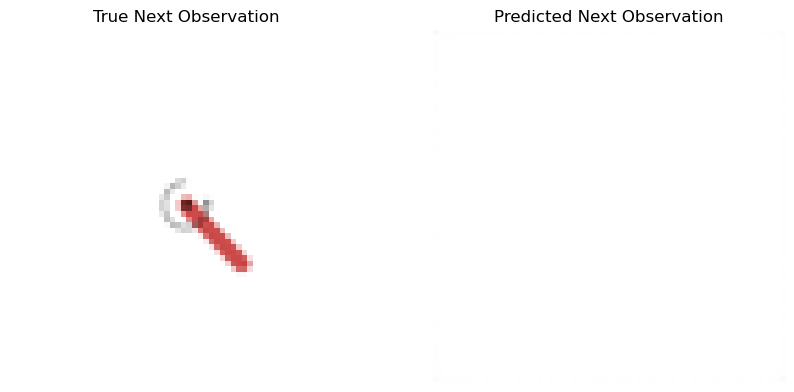

In [26]:
enc.eval()
dec.eval()
world_model.eval()

with torch.no_grad():
    o, info = env.reset()
    action = env.action_space.sample()

    # true next step from environment
    next_o, reward, done, truncated, info = env.step(action)

    # prepare tensors
    state_tensor = torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0) / 255.0
    action_tensor = torch.tensor(action, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    # encode current state to latent
    s_latent = enc(state_tensor)

    # predict next latent via world model
    s_pred_latent = world_model(s_latent, action_tensor)

    # decode predicted latent -> image
    pred_img = dec(s_pred_latent).cpu().squeeze(0).numpy().transpose(1, 2, 0)

    # true next image (already in numpy HWC from env.step)
    true_img = next_o.transpose(1, 2, 0) / 255.0

    # show both
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("True Next Observation")
    plt.imshow(true_img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Predicted Next Observation")
    plt.imshow(pred_img)
    plt.axis("off")

    plt.show()


In [32]:
print(pred_img.min(), true_img.min())
print(pred_img.max(), true_img.max())

0.97991425 0.10196078431372549
1.0 1.0


[0.         0.         0.         0.10141344 0.         0.
 0.         0.         0.         0.         0.04431867 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.06656302 0.         0.         0.0672821
 0.04952691 0.08530974 0.         0.         0.06216335 0.06136754
 0.         0.         0.         0.         0.08184294 0.
 0.00850215 0.08592364 0.         0.         0.         0.
 0.         0.         0.02586202 0.00979726 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.02784548 0.07030118 0.
 0.00386831 0.         0.         0.        ]
[ 1.9347107e-02  2.4506086e-03 -2.0525106e-03  8.9733176e-02
 -3.7789599e-03  5.9491750e-03  1.8158578e-05  2.2497959e-05
 -8.3585328e-04 -7.8630503e-03  5.0432954e-02  3.5017377e-03
 -9.9662552e-04  1.3600064e-03 -7.7014542e-03 -2.6456323e-03
  1.0429101e-02  2.9863822e-03 -2.6453072e-03 -2.4879595e-02
  6.6898584e-02 -9.7709373e-03  3.2200613e-0

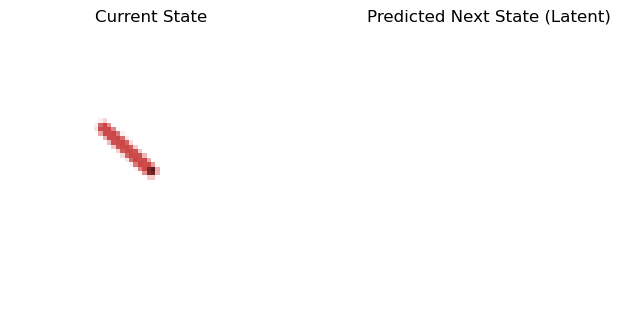

In [ ]:
enc.eval()
world_model.eval()
with torch.no_grad():
    o, info = env.reset()
    for _ in range(1):
        state = torch.tensor(o, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        if enc is not None:
            state = enc(state/255.0)

        # print(state.detach().cpu().squeeze(0).numpy()) # for inspection
        action = env.action_space.sample()
        action_tensor = torch.tensor(action, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        predicted_next_state = world_model(state, action_tensor)
        # print(predicted_next_state.detach().cpu().squeeze(0).numpy()) # for inspection
        reconst_image = dec(predicted_next_state).detach().cpu().squeeze(0).numpy().transpose(1, 2, 0)
        # predicted_next_state = predicted_next_state.cpu().squeeze(0).numpy()
        # show the image for the current state and the predicted next state
        plt.figure(figsize=(8, 4))
        if env.use_images:
            plt.subplot(1, 2, 1)
            plt.title("Current State")
            plt.imshow(o.transpose(1, 2, 0))
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.title("Predicted Next State (Latent)")
            # Placeholder: In practice, decode the latent to image
            # print(dec(predicted_next_state).shape)
            plt.imshow(reconst_image)  # Replace with decoded image
            print(reconst_image)
            plt.axis('off')

In [ ]:
reconst_image

array([[[0.99994993, 0.99981815, 0.9998411 ],
        [1.        , 1.        , 1.        ],
        [0.99999976, 1.        , 1.        ],
        ...,
        [0.9999994 , 1.        , 1.        ],
        [0.99999726, 0.99999964, 1.        ],
        [0.99945503, 0.99993885, 0.9998449 ]],

       [[0.99999726, 0.99999905, 0.99999964],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 0.9999993 , 0.99999905]],

       [[0.9999999 , 0.9999993 , 0.99999964],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [0.99999905, 1.        , 0.9999999 ]],

       ...,

       [[0.9999999 , 0.9999999 , 0.9999995 ],
        [1.        , 1.        , 1.        ],
        [1.        , 1

In [23]:
# object.__dict__

In [ ]:
import torch
import numpy as np
from torch import nn, optim 
import torch.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



class WorldModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(WorldModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim)  # Predict next state only
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)

class RewardModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=16):
        super(RewardModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim + state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # Predict reward
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0
    
    def push(self, state, action, reward, next_state):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state)
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size=64):
        batch = torch.randperm(len(self.buffer))[:batch_size]
        state, action, reward, next_state = map(torch.stack, zip(*[self.buffer[i] for i in batch]))
        return state, action, reward, next_state
    
    def batch_sample(self, batch_size=64):
        # ensure we use Python ints for indexing and handle stored tensor elements correctly
        indices = torch.randperm(len(self.buffer))[:batch_size].tolist()
        states, actions, rewards, next_states = zip(*[self.buffer[idx] for idx in indices])
        # If the stored elements are already torch.Tensors, stack them directly.
        if isinstance(states[0], torch.Tensor):
            states = torch.stack(states).to(DEVICE)
            actions = torch.stack(actions).to(DEVICE)
            rewards = torch.stack(rewards).to(DEVICE)
            next_states = torch.stack(next_states).to(DEVICE)
        else:
            # fallback if numpy arrays were stored
            states = torch.tensor(states, dtype=torch.float32).to(DEVICE)
            actions = torch.tensor(actions, dtype=torch.float32).to(DEVICE)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
            next_states = torch.tensor(next_states, dtype=torch.float32).to(DEVICE)
        return states, actions, rewards, next_states
    
    def __len__(self):
        return len(self.buffer)



env = gym.make("Pendulum-v1", render_mode="rgb_array", g=10.0)
# env = Env("Pendulum-v1", use_images=True, seed=42)
o, info = env.reset(seed=42)

# init wm
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
world_model = WorldModel(state_dim, action_dim)
optimizer = optim.Adam(world_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# init reward model
reward_model = RewardModel(state_dim, action_dim)
reward_optimizer = optim.Adam(reward_model.parameters(), lr=0.001)
reward_loss_fn = nn.MSELoss()


def modified_step(self, u):
    '''Adding stochasticity from "wind" to the Pendulum environment'''
    def angle_normalize(x):
        return ((x + np.pi) % (2 * np.pi)) - np.pi
    
    th, thdot = self.state  # th := theta

    g = self.g
    m = self.m
    l = self.l
    dt = self.dt

    # add some biased noise to the action
    u += np.random.normal(0, 0.1) + 0.5  # bias the torque to the right

    u = np.clip(u, -self.max_torque, self.max_torque)[0]
    self.last_u = u  # for rendering
    costs = angle_normalize(th) ** 2 + 0.1 * thdot**2 + 0.001 * (u**2)

    newthdot = thdot + (3 * g / (2 * l) * np.sin(th) + 3.0 / (m * l**2) * u) * dt
    newthdot = np.clip(newthdot, -self.max_speed, self.max_speed)
    newth = th + newthdot * dt

    self.state = np.array([newth, newthdot])

    if self.render_mode == "human":
        self.render()
    # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
    return self._get_obs(), -costs, False, False, {}


# # bind the modified_step function to this env instance so `self` is passed automatically
# env.step = types.MethodType(modified_step, env)
# o, info = env.reset(seed=42)
# init buffer
replay_buffer = ReplayBuffer(capacity=10000)
def sample_from_replay_buffer(batch_size=64):
    return replay_buffer.batch_sample(batch_size)

# learn the transition dynamics
num_epochs = 500
batch_size = 64
losses = []
reward_losses = []
for epoch in range(num_epochs):
    o = env.reset()[0]
    for _ in range(64):  # Collect some data
        action = env.action_space.sample()
        noisy_action = action + np.random.normal(0, 2) + 1.1  # bias the torque to the right
        next_o, reward, done, truncated, info = env.step(noisy_action)
        # Store transition (o, action, reward, next_o)
        replay_buffer.push(torch.tensor(o, dtype=torch.float32).to(DEVICE),
                           torch.tensor(action, dtype=torch.float32).to(DEVICE),
                           torch.tensor(reward, dtype=torch.float32).to(DEVICE),
                           torch.tensor(next_o, dtype=torch.float32).to(DEVICE))
        o = next_o
        if done or truncated:
            o, info = env.reset()


    # Sample a batch from the replay buffer
    states, actions, rewards, next_states = sample_from_replay_buffer(batch_size)

    # Train the world model
    preds = world_model(states, actions)
    loss = loss_fn(preds, next_states)
    # loss = loss_fn(preds, torch.cat([next_states, rewards.unsqueeze(-1)], dim=-1))

    # Train the reward model
    reward_preds = reward_model(states, actions, next_states)
    reward_loss = reward_loss_fn(reward_preds, rewards.unsqueeze(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_optimizer.zero_grad()
    reward_loss.backward()
    reward_optimizer.step()

    losses.append(loss.item())
    reward_losses.append(reward_loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Reward Loss: {reward_loss.item():.4f}")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(losses, label='Transition Loss')
ax[1].plot(reward_losses, label='Reward Loss', color='orange')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("World Model Training Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Reward Model Training Loss")
ax[0].legend()
ax[1].legend()

Using device: cuda


TypeError: Env.reset() got an unexpected keyword argument 'seed'

    def step(self, u):
        th, thdot = self.state  # th := theta

        g = self.g
        l = self.l
        m = self.m
        dt = self.dt

        u = np.clip(u, -self.max_torque, self.max_torque)[0]
        self.last_u = u  # for rendering
        costs = angle_normalize(th) ** 2 + 0.1 * thdot**2 + 0.001 * (u**2)

        newthdot = thdot + (3 * g / (2 * l) * np.sin(th) + 3.0 / (m * l**2) * u) * dt
        newthdot = np.clip(newthdot, -self.max_speed, self.max_speed)
        newth = th + newthdot * dt

        self.state = np.array([newth, newthdot])

        if self.render_mode == "human":
            self.render()
        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        return self._get_obs(), -costs, False, False, {}

In [61]:
with torch.no_grad():
    test_state = torch.tensor(o, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    test_action = torch.tensor(env.action_space.sample(), dtype=torch.float32).unsqueeze(0).to(DEVICE)
    predicted_next_state = world_model(test_state, test_action)
    predicted_reward = reward_model(test_state, test_action, predicted_next_state)
    print(f"Current State: {test_state.cpu().numpy()}")
    print(f"Action Taken: {test_action.cpu().numpy()}")
    print(f"Predicted Next State: {predicted_next_state.cpu().numpy()}")
    print(f"Predicted Reward: {predicted_reward.cpu().numpy()}")
    print(f"Actual Next State: {next_states[0].cpu().numpy()}")
    print(f"Actual Reward: {rewards[0].cpu().numpy()}")


RuntimeError: Tensors must have same number of dimensions: got 4 and 2

In [33]:
class MPCPlanner(object):

    def __init__(
        self, 
        world_model,
        reward_model,
        current_state,
        action_space, 
        horizon=5,
        num_simulations=100, # number of action sequences to simulate from
        cost_func=None,
        device=DEVICE,
    ):
        super().__init__()
        self.world_model = world_model
        self.reward_model = reward_model
        self.current_state = current_state
        self.action_space = action_space
        self.horizon = horizon
        self.num_simulations = num_simulations
        self.cost_func = cost_func
        self.device = device
        self.action_dim = action_space.shape[0]
        self.state_dim = current_state.shape[0]
    

    def plan(self):
        
        best_seq = None
        best_trajectory = None
        best_reward = -float('inf')

        for _ in range(self.num_simulations):
            # sample a single action sequence of shape (horizon, action_dim)
            action_seq = self.sample_action_sequences()
            state = self.current_state.unsqueeze(0)  # shape (1, state_dim)
            trajectory = [state.detach().cpu().numpy()]
            _return = 0

            for t in range(self.horizon):
                action = action_seq[t].unsqueeze(0)  # shape (1, action_dim)
                with torch.no_grad():
                    next_state = self.world_model(state, action)
                    reward = self.reward_model(state, action, next_state).squeeze(0) # shape ()
                # next_state already has batch dim (1, state_dim), no extra unsqueeze
                trajectory.append(next_state.detach().cpu().numpy())
                _return += reward.item()
                state = next_state

            if _return > best_reward:
                best_reward = _return
                best_seq = action_seq
                best_trajectory = trajectory
        
        return best_seq, best_trajectory, best_reward

            

    # def eval_trajectory(self, trajectory):
    #     pass




    def sample_action_sequences(self):
        # return a single sequence of actions with shape (horizon, action_dim)
        arr = np.random.uniform(
                self.action_space.low, 
                self.action_space.high, 
                size=(self.horizon, self.action_dim)
            ).astype(np.float32)
        return torch.from_numpy(arr).to(self.device)




mpc = MPCPlanner(
    world_model=world_model,
    reward_model=reward_model,
    current_state=torch.tensor(o, dtype=torch.float32).to(DEVICE),
    action_space=env.action_space,
    horizon=5,
    num_simulations=100,
    device=DEVICE,
)

best_seq, best_trajectory, best_reward = mpc.plan()
print("Best Action Sequence:\n", best_seq)
print("Best Trajectory:\n", best_trajectory)
print("Best Reward:\n", best_reward)


Best Action Sequence:
 tensor([[-1.4904],
        [-0.7211],
        [-0.6035],
        [-0.2803],
        [-0.2189]], device='cuda:0')
Best Trajectory:
 [array([[-0.8650226 ,  0.5017329 , -0.03817914]], dtype=float32), array([[-0.83620626,  0.4989898 , -0.05822165]], dtype=float32), array([[-0.8027388 ,  0.5112791 , -0.04935054]], dtype=float32), array([[-0.7772169 ,  0.524383  , -0.05528262]], dtype=float32), array([[-0.7853893 ,  0.54311085, -0.08328529]], dtype=float32), array([[-0.79954624,  0.56200796, -0.11465599]], dtype=float32)]
Best Reward:
 -34.85762929916382


In [ ]:
# test generalization of transition predictions to new gravity
env = gym.make("Pendulum-v1", render_mode="rgb_array", g=12.0)

o, info = env.reset(seed=42)
test_next_states = []
test_rewards = []
for _ in range(1000):
    a = env.action_space.sample()
    next_o, r, done, truncated, info = env.step(a)
    test_next_states.append(next_o)
    test_rewards.append(r)
    o = next_o
    if done or truncated:
        o, info = env.reset()



IndexError: too many indices for tensor of dimension 1

In [26]:
x = torch.linspace(-10, 10, 10000)
x = x.reshape(-1, 1)
x

y = torch.sin(x) + 0.1 * torch.randn_like(x)
y

tensor([[ 0.5766],
        [ 0.4995],
        [ 0.6028],
        ...,
        [-0.5903],
        [-0.6272],
        [-0.5120]])

In [ ]:
import matplotlib.pyplot as plt
import torch
from engression import engression
from engression.data.simulator import preanm_simulator
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N = 50_000
x = torch.linspace(-50, 50, N)
x_eval = torch.linspace(-60, 60, N // 10)
y = torch.sin(x) + 0.1 * torch.randn_like(x)
y_eval = torch.sin(x_eval) + 0.1 * torch.randn_like(x_eval)
y_perfect = torch.sin(x)
y_eval_perfect = torch.sin(x_eval)


engressor = engression(x.reshape(-1,1), y.reshape(-1,1), lr=0.01, num_epochs=1_000, batch_size=1_000, device=device)


Using device: cuda
GPU is available, running on GPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 1000.
[Epoch 1 (0%), batch 99] energy-loss: 0.5931,  E(|Y-Yhat|): 1.2426,  E(|Yhat-Yhat'|): 1.2990
[Epoch 100 (10%), batch 99] energy-loss: 0.5794,  E(|Y-Yhat|): 1.1791,  E(|Yhat-Yhat'|): 1.1995
[Epoch 200 (20%), batch 99] energy-loss: 0.5726,  E(|Y-Yhat|): 1.1515,  E(|Yhat-Yhat'|): 1.1578
[Epoch 300 (30%), batch 99] energy-loss: 0.5744,  E(|Y-Yhat|): 1.1522,  E(|Yhat-Yhat'|): 1.1557
[Epoch 400 (40%), batch 99] energy-loss: 0.5723,  E(|Y-Yhat|): 1.1559,  E(|Yhat-Yhat'|): 1.1671
[Epoch 500 (50%), batch 99] energy-loss: 0.5757,  E(|Y-Yhat|): 1.1577,  E(|Yhat-Yhat'|): 1.1640
[Epoch 600 (60%), batch 99] energy-loss: 0.5762,  E(|Y-Yhat|): 1.1553,  E(|Yhat-Yhat'|): 1.158

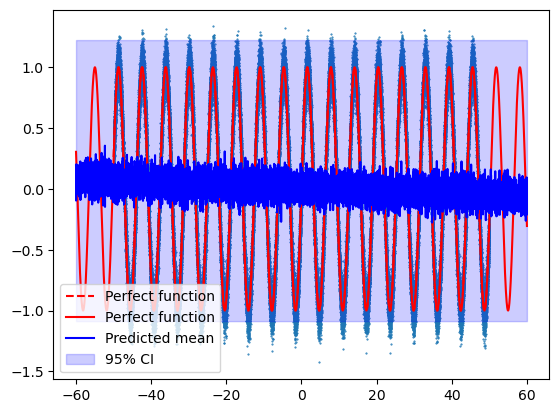

In [36]:
y_pred_mean = engressor.predict(x_eval, target="mean").cpu().detach().numpy() ## for the conditional mean
y_pred_med = engressor.predict(x_eval, target="median").cpu().detach().numpy() ## for the conditional median
y_pred_quant = engressor.predict(x_eval, target=[0.025, 0.5, 0.975]) ## for the conditional 2.5% and 97.5% quantiles

plt.scatter(x, y, marker='.', s=1)
plt.plot(x, y_perfect, color='red', linestyle='dashed', label='Perfect function')
plt.plot(x_eval, y_eval_perfect, color='red', label='Perfect function')
plt.plot(x_eval, y_pred_mean, color='blue', label='Predicted mean')
plt.fill_between(x_eval, y_pred_quant[0][0].cpu().detach().numpy(), y_pred_quant[2][0].cpu().detach().numpy(), color='blue', alpha=0.2, label='95% CI')
plt.legend()
plt.show()

In [39]:
import stable_baselines3 as sb3
from stable_baselines3.common.env_util import make_vec_env
import gymnasium as gym

env = make_vec_env("CartPole-v1", n_envs=1)
model = sb3.PPO("MlpPolicy", env, verbose=1, device=device)
model.learn(total_timesteps=10_000)

obs = env.reset()
for _ in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = env.step(action)
    env.render()

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.4     |
|    ep_rew_mean     | 21.4     |
| time/              |          |
|    fps             | 1080     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26.2        |
|    ep_rew_mean          | 26.2        |
| time/                   |             |
|    fps                  | 878         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008665331 |
|    clip_fraction        | 0.101       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | 0.0082      |
|    learnin

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


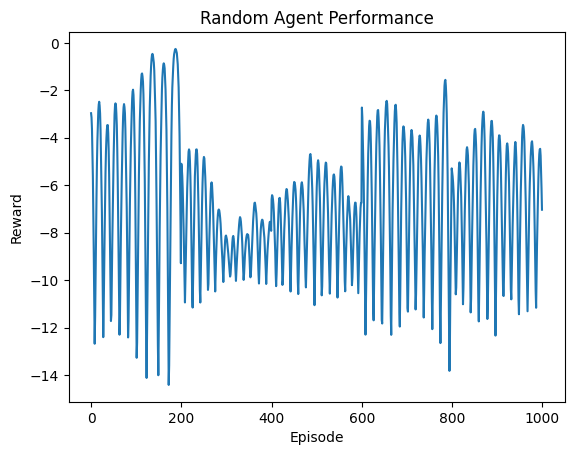

In [19]:

import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

rewards = []
for _ in range(1000):
    # env.render()
    action = env.action_space.sample()  
    observation, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        observation, info = env.reset()

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

Episode 10/120, avg reward (last 10): -1088.43
Episode 20/120, avg reward (last 10): -790.19
Episode 30/120, avg reward (last 10): -913.12
Episode 40/120, avg reward (last 10): -999.33
Episode 50/120, avg reward (last 10): -932.85
Episode 60/120, avg reward (last 10): -703.27
Episode 70/120, avg reward (last 10): -720.44
Episode 80/120, avg reward (last 10): -693.55
Episode 90/120, avg reward (last 10): -925.44
Episode 100/120, avg reward (last 10): -1147.41
Episode 110/120, avg reward (last 10): -1502.58
Episode 120/120, avg reward (last 10): -1006.37


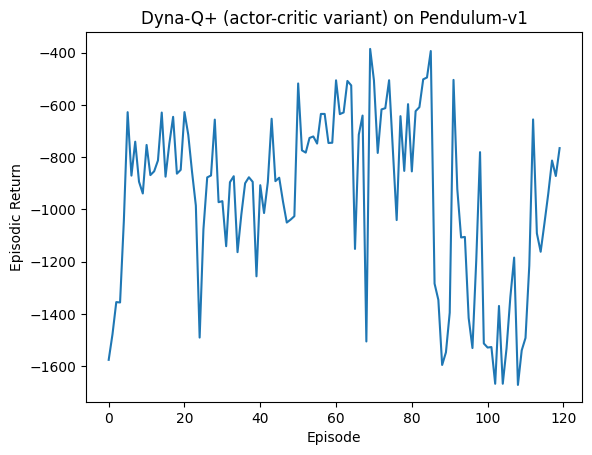

In [21]:
# dyna_q_plus_pendulum.py
import random
import collections
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
import gymnasium as gym
import math
import matplotlib.pyplot as plt

# -------------------------
# Model classes (fixed)
# -------------------------
class QNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa).squeeze(-1)  # return shape (batch,)

class PNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=128):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, state_dim),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)

class RNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2 * state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x).squeeze(-1)

class PiNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64, action_scale=2.0):
        super().__init__()
        self.action_scale = action_scale
        self.net = nn.Sequential(
            nn.Linear(state_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, action_dim),
        )

    def forward(self, state):
        # map outputs to [-action_scale, action_scale]
        raw = self.net(state)
        return torch.tanh(raw) * self.action_scale

# -------------------------
# Replay / Model Buffer
# -------------------------
# We'll keep a buffer of real transitions for training, and a "model memory"
# for planning updates storing (state, action, next_state, reward, last_seen_time).
Transition = collections.namedtuple("Transition", ["s","a","s2","r","t"])

class ModelMemory:
    def __init__(self):
        self.data = []  # list of Transition
    def add(self, s, a, s2, r, t):
        self.data.append(Transition(s,a,s2,r,t))
    def sample(self, n):
        return random.sample(self.data, min(n, len(self.data)))
    def __len__(self):
        return len(self.data)

# -------------------------
# DynaQ+ agent
# -------------------------
class DynaQPlus:
    def __init__(self, env,
                 gamma=0.99,
                 alpha_q=1e-3,
                 alpha_model=1e-3,
                 alpha_pi=1e-4,
                 planning_steps=50,
                 kappa=1e-3,
                 batch_size=64,
                 device='cpu'):

        self.env = env
        self.device = device
        self.gamma = gamma
        self.planning_steps = planning_steps
        self.kappa = kappa
        self.batch_size = batch_size

        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.shape[0]
        # action range (Pendulum is -2..2)
        self.action_high = float(env.action_space.high[0])
        self.action_low = float(env.action_space.low[0])

        # models
        self.Q = QNet(self.state_dim, self.action_dim).to(self.device)
        self.P = PNet(self.state_dim, self.action_dim).to(self.device)
        self.R = RNet(self.state_dim, self.action_dim).to(self.device)
        self.Pi = PiNet(self.state_dim, self.action_dim, action_scale=self.action_high).to(self.device)

        # opts
        self.q_opt = optim.Adam(self.Q.parameters(), lr=alpha_q)
        self.p_opt = optim.Adam(self.P.parameters(), lr=alpha_model)
        self.r_opt = optim.Adam(self.R.parameters(), lr=alpha_model)
        self.pi_opt = optim.Adam(self.Pi.parameters(), lr=alpha_pi)

        # replay buffers
        self.real_buffer = []   # store raw real transitions for minibatch training of models and Q
        self.model_mem = ModelMemory()  # model memory with timestamps for Dyna planning
        self.time = 0

    def select_action(self, state, noise_scale=0.1):
        s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            a = self.Pi(s).cpu().numpy()[0]
        # add small exploration noise in behaviour
        a = a + noise_scale * np.random.randn(*a.shape)
        return np.clip(a, self.action_low, self.action_high)

    def store_real(self, s, a, s2, r):
        self.real_buffer.append((s, a, s2, r))
        self.time += 1
        # store into model memory with current timestamp for planning
        self.model_mem.add(np.array(s), np.array(a), np.array(s2), float(r), int(self.time))

    def train_models(self, epochs=1):
        if len(self.real_buffer) < 8:
            return
        for _ in range(epochs):
            batch = random.sample(self.real_buffer, min(len(self.real_buffer), self.batch_size))
            s_b = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=self.device)
            a_b = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32, device=self.device)
            s2_b = torch.tensor(np.array([b[2] for b in batch]), dtype=torch.float32, device=self.device)
            r_b = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=self.device)

            # dynamics loss
            pred_s2 = self.P(s_b, a_b)
            loss_p = F.mse_loss(pred_s2, s2_b)
            self.p_opt.zero_grad(); loss_p.backward(); self.p_opt.step()

            # reward loss
            pred_r = self.R(s_b, a_b, s2_b)
            loss_r = F.mse_loss(pred_r, r_b)
            self.r_opt.zero_grad(); loss_r.backward(); self.r_opt.step()

    def critic_update(self, s, a, r, s2):
        # s,a,s2 are numpy arrays or tensors convertible
        s_t = torch.tensor(np.array(s), dtype=torch.float32, device=self.device).unsqueeze(0)
        a_t = torch.tensor(np.array(a), dtype=torch.float32, device=self.device).unsqueeze(0)
        s2_t = torch.tensor(np.array(s2), dtype=torch.float32, device=self.device).unsqueeze(0)
        r_t = torch.tensor(float(r), dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            a_next = self.Pi(s2_t)
            q_next = self.Q(s2_t, a_next)
            target = r_t + self.gamma * q_next

        q_val = self.Q(s_t, a_t)
        loss_q = F.mse_loss(q_val, target)

        self.q_opt.zero_grad()
        loss_q.backward()
        self.q_opt.step()
        return loss_q.item()

    def policy_update(self, states_batch):
        # states_batch: list or array of states
        s_b = torch.tensor(np.array(states_batch), dtype=torch.float32, device=self.device)
        a_pred = self.Pi(s_b)
        # objective: maximize Q(s, Pi(s)) -> minimize negative
        q_vals = self.Q(s_b, a_pred)
        # we maximize mean q, so minimize -mean(q)
        loss_pi = - q_vals.mean()

        self.pi_opt.zero_grad()
        loss_pi.backward()
        self.pi_opt.step()
        return loss_pi.item()

    def planning_updates(self, n_planning):
        # sample from model memory, compute exploration-bonus augmented reward,
        # use predicted next state and reward from learned models for planning updates
        if len(self.model_mem) == 0:
            return
        for _ in range(n_planning):
            tran = random.choice(self.model_mem.data)
            s = tran.s
            a = tran.a
            t_last = tran.t
            # compute bonus
            delta_t = max(1, self.time - t_last)
            bonus = self.kappa * math.sqrt(delta_t)

            s_t = torch.tensor(s, dtype=torch.float32, device=self.device).unsqueeze(0)
            a_t = torch.tensor(a, dtype=torch.float32, device=self.device).unsqueeze(0)
            # predict next state & reward from model
            with torch.no_grad():
                s2_pred = self.P(s_t, a_t)
                r_pred = self.R(s_t, a_t, s2_pred)
            # augmented reward
            r_aug = (r_pred + bonus).detach().cpu().numpy().item()
            # do a critic update using (s,a,r_aug,s2_pred)
            # convert s2_pred back to numpy for critic_update convenience
            s2_np = s2_pred.detach().cpu().numpy()[0]
            self.critic_update(s, a, r_aug, s2_np)

    def train(self, num_episodes=200, max_steps=200,
              initial_random_steps=500, model_epochs=1, print_every=10,
              noise_scale=0.2):

        episode_rewards = []
        obs, _ = self.env.reset(seed=42)

        # bootstrap with some random interactions
        for _ in range(initial_random_steps):
            a = self.env.action_space.sample()
            s2, r, done, term, info = self.env.step(a)
            self.store_real(obs, a, s2, r)
            obs = s2
            if done or term:
                obs, _ = self.env.reset()

        for ep in range(num_episodes):
            obs, _ = self.env.reset()
            total_r = 0.0
            for t in range(max_steps):
                a = self.select_action(obs, noise_scale=noise_scale)
                s2, r, done, term, info = self.env.step(a)
                total_r += r
                # store
                self.store_real(obs, a, s2, r)

                # 1) train models on real data
                self.train_models(epochs=model_epochs)

                # 2) real critic update (one step)
                self.critic_update(obs, a, r, s2)

                # 3) policy update (use a minibatch of recent states)
                # sample states for policy update (if not enough, use latest)
                if len(self.real_buffer) >= self.batch_size:
                    states_batch = [x[0] for x in random.sample(self.real_buffer, self.batch_size)]
                else:
                    states_batch = [x[0] for x in self.real_buffer]
                _ = self.policy_update(states_batch)

                # 4) planning (Dyna-Q+ updates)
                self.planning_updates(self.planning_steps)

                obs = s2
                if done or term:
                    break

            episode_rewards.append(total_r)
            if (ep + 1) % print_every == 0:
                print(f"Episode {ep+1}/{num_episodes}, avg reward (last {print_every}): {np.mean(episode_rewards[-print_every:]):.2f}")

        return episode_rewards

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    env = gym.make("Pendulum-v1")
    agent = DynaQPlus(env,
                      gamma=0.98,
                      alpha_q=1e-3,
                      alpha_model=1e-3,
                      alpha_pi=1e-4,
                      planning_steps=30,
                      kappa=1e-3,
                      batch_size=64,
                      device='cpu')
    rewards = agent.train(num_episodes=120, max_steps=200,
                          initial_random_steps=400, model_epochs=2, print_every=10, noise_scale=0.15)

    plt.plot(rewards)
    plt.xlabel("Episode")
    
    plt.ylabel("Episodic Return")
    plt.title("Dyna-Q+ (actor-critic variant) on Pendulum-v1")
    plt.show()


In [ ]:
import torch
from torch import nn, optim
import torch.functional as F


class Q(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(Q, self).__init__()
        self.model = nn.Sequential(
            # q(s, a) -> value
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)
    

class P(nn.Module):
    def __init__(self, state_dim, action_dim, dim=32):
        super(P, self).__init__()
        self.model = nn.Sequential(
            # p(s, a) -> s'
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, state_dim),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)


class R(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(R, self).__init__()
        self.model = nn.Sequential(
            # r(s, a, s') -> reward
            nn.Linear(2 * state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action, next_state):
        sa_next = torch.cat([state, action, next_state], dim=-1)
        return self.model(sa_next)


class Pi(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(Pi, self).__init__()
        self.model = nn.Sequential(
            # pi(s) -> a
            nn.Linear(state_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, action_dim),
            nn.Tanh() * 2,  # Assuming action space is normalized between -2 and 2
        )

    def forward(self, state):
        return self.model(state)


class DynaQplus():
    
    def __init__(self, env, steps, planning_steps, alpha, gamma, epsilon, kappa):
        super(DynaQplus, self).__init__()
        self.env = env
        self.steps = steps
        self.planning_steps = planning_steps
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.kappa = kappa

        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.shape[0]

        self._init_Q_func()
        self._init_dynamics_model()
        self._init_reward_model()

    def _init_Q_func(self, dim=16):
        '''initialize a MLP for Q function'''
        self.Q = Q(self.state_dim, self.action_dim, dim)
        self.Q_optim = optim.Adam(self.Q.parameters(), lr=1e-3)

    def _init_dynamics_model(self, dim=32):
        '''initialize a MLP for dynamics model'''
        self.P = P(self.state_dim, self.action_dim, dim)
        self.P_optim = optim.Adam(self.P.parameters(), lr=1e-3)

    def _init_reward_model(self, dim=16):
        '''initialize a MLP for reward model'''
        self.R = R(self.state_dim, self.action_dim, dim)
        self.R_optim = optim.Adam(self.R.parameters(), lr=1e-3)

    def _init_policy(self, dim=16):
        '''initialize a MLP for policy'''
        self.Pi = Pi(self.state_dim, self.action_dim, dim)
        self.Pi_optim = optim.Adam(self.Pi.parameters(), lr=1e-3)

    def policy(self, state, samples=10):
        '''epsilon-greedy policy'''
        if torch.rand(1).item() < self.epsilon:
            return self.env.action_space.sample()
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad(): # prevent gradients
                action = self.Pi(state_tensor)
            return action.squeeze(0).numpy()
        

    
    def train(self, episodes=100):
        loss_dict = {'Q': [], 'P': [], 'R': [], 'Pi': []}
        for episode in range(episodes):
            state, info = self.env.reset()
            total_reward = 0
            for step in range(self.steps):
                action = self.policy(state)
                next_state, reward, terminated, truncated, info = self.env.step(action)
                total_reward += reward
                # update Q function
                with torch.no_grad():
                    q_now = self.Q(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                   torch.tensor(action, dtype=torch.float32).unsqueeze(0))
                    q_next = self.Q(torch.tensor(next_state, dtype=torch.float32).unsqueeze(0),
                                    self.Pi(torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)))        
                    target = q_now + self.alpha * (reward + self.gamma * q_next - q_now)
                    loss = nn.MSELoss()(q_now, target)
                self.Q_optim.zero_grad()
                loss.backward()
                self.Q_optim.step()
                loss_dict['Q'].append(loss.item())

                # update dynamics model
                with torch.no_grad():
                    pred_next_state = self.P(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                             torch.tensor(action, dtype=torch.float32).unsqueeze(0))
                    loss = nn.MSELoss()(pred_next_state, torch.tensor(next_state, dtype=torch.float32).unsqueeze(0))
                self.P_optim.zero_grad()
                loss.backward()
                self.P_optim.step()
                loss_dict['P'].append(loss.item())
                
                # update reward model
                with torch.no_grad():
                    pred_reward = self.R(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                         torch.tensor(action, dtype=torch.float32).unsqueeze(0),
                                         torch.tensor(next_state, dtype=torch.float32).unsqueeze(0))
                    loss = nn.MSELoss()(pred_reward, torch.tensor(reward, dtype=torch.float32).unsqueeze(0).unsqueeze(0))
                self.R_optim.zero_grad()
                loss.backward()
                self.R_optim.step()
                loss_dict['R'].append(loss.item())

                # # update policy
                # with torch.no_grad():

                state = next_state
                if terminated or truncated:
                    break
            print(f"Episode {episode+1}, Total Reward: {total_reward}")




In [18]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ===== 1. Dynamics Model (World Model) =====
class DynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)


# ===== 2. Collect real data =====
def collect_data(env, policy, episodes=10, max_steps=200):
    data = []
    for _ in range(episodes):
        obs, _ = env.reset()
        for _ in range(max_steps):
            action = policy(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            data.append((obs, action, next_obs, reward))
            obs = next_obs
            if terminated or truncated:
                break
    return data


# ===== 3. Train world model =====
def train_world_model(model, data, epochs=30, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    states = torch.tensor(np.array([d[0] for d in data]), dtype=torch.float32)
    actions = torch.tensor(np.array([d[1] for d in data]), dtype=torch.float32)
    next_states = torch.tensor(np.array([d[2] for d in data]), dtype=torch.float32)

    for epoch in range(epochs):
        pred_next = model(states, actions)
        loss = loss_fn(pred_next, next_states)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


# ===== 4. MPC Planner (Random Shooting) =====
def plan_action(model, state, horizon=20, n_candidates=100, action_low=-2.0, action_high=2.0):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    best_return = -1e9
    best_action = None

    for _ in range(n_candidates):
        # sample candidate sequences with correct action dimension
        actions = np.random.uniform(action_low, action_high, size=(horizon, action_dim))
        total_reward = 0.0
        s = state_tensor.clone()

        # Simulate rollout in learned model
        for a in actions:
            # ensure a is shape (1, action_dim) and float32
            a_np = np.asarray(a, dtype=np.float32).reshape(1, action_dim)
            a_tensor = torch.from_numpy(a_np)
            s = model(s, a_tensor)
            # simple reward approximation (cos(theta)-cost)
            theta_cos = s[0, 0]
            theta_dot = s[0, 2]
            # use scalar value for action cost
            a_val = float(a_np.ravel()[0])
            reward = theta_cos - 0.1 * (theta_dot**2) - 0.001 * (a_val**2)
            total_reward += reward.item()

        if total_reward > best_return:
            best_return = total_reward
            best_action = actions[0]

    return np.clip(best_action, action_low, action_high)


# ===== 5. Main training loop =====
env = gym.make("Pendulum-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# Initialize world model
model = DynamicsModel(state_dim, action_dim)

# Initial random data collection
buffer = collect_data(env, policy=lambda obs: env.action_space.sample(), episodes=20)

rewards_per_iter = []

for iteration in range(15):  # 15 model-based iterations
    print(f"=== Iteration {iteration} ===")
    # Collect data using MPC with learned model
    rewards = []
    for ep in range(5):
        obs, _ = env.reset()
        ep_reward = 0
        prev_obs = None
        for t in range(200):
            prev_obs = obs.copy()
            action = plan_action(model, obs, horizon=20, n_candidates=200)
            # action is a numpy array of shape (action_dim,), pass it directly
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
        # store the last transition properly: (state, action, next_state, reward)
        if prev_obs is not None:
            buffer.append((prev_obs, action, obs, reward))
            break
        rewards.append(ep_reward)
        buffer.append((obs, [action], obs, reward))  # store last transition
    avg_reward = np.mean(rewards)
    rewards_per_iter.append(avg_reward)
    print(f"Average reward: {avg_reward:.2f}")

env.close()

# ===== 6. Plot Learning Curve =====
plt.plot(rewards_per_iter)
plt.xlabel("Model-Based Iteration")
plt.ylabel("Average Return")
plt.title("MBRL on Pendulum (Random Shooting MPC)")
plt.grid()
plt.show()


=== Iteration 0 ===
Average reward: -1303.36
=== Iteration 1 ===
Average reward: -1126.15
=== Iteration 2 ===
Average reward: -1150.45
=== Iteration 3 ===
Average reward: -1305.00
=== Iteration 4 ===


KeyboardInterrupt: 

In [ ]:

def dynaQplus():
